# ADS 508 Final Team Project

# Nutri Access Analytics

## Group 3: James Shoenhair, Shery Thaker, and Nancy Walker 

## Introduction 

The goal of this project is to develop a data pipeline and analytical workflow for a hypothetical company focused on improving public health outcomes through data-driven decision-making. This company aims to identify patterns in food access, socioeconomic conditions, and health outcomes to better understand and address disparities across California counties.

To support this objective, We designed a modular Python pipeline using Amazon S3 for storage of raw and processed data, AWS Glue Data Catalog to register curated datasets stored in S3, and Amazon Athena to query the processed data in a serverless way. Amazon SageMaker was used for exploratory analysis and cloud-based model training. The final county-level modeling dataset was stored in Parquet format to support efficient querying and downstream machine learning workflows.

## AWS Services Used 

This project uses multiple AWS services to support a cloud-based analytics and machine learning workflow:

    - Amazon S3 stores raw, processed, and final datasets 
    
    - AWS Glue Data Catalog registers processed datasets stored in S3 so they can be queried as structured tables 
    
    - Amazon Athena enables serverless SQL queries against curated project data stored in S3 
    
    - Amazon SageMaker supports notebook development, exploratory analysis, and machine learning training in the AWS environment 

### Research Questions:

**Can food environment, demographic, and health-related features be used to predict communities at high risk of limited food access?**
    
    - Which communities exhibit characteristics associated with limited access to healthy food resources (i.e., potential food deserts)?

    - How do demographic and socioeconomic factors vary across communities with different levels of food access?

    - How do geographic patterns of food access and retail food availability vary across counties, particularly within California?

### Running all cells:
    1.	raw data lands in S3 
    2.	pipeline cleans and writes processed outputs back to S3 
    3.	Glue Data Catalog registers processed CSV/Parquet files as tables 
    4.	Athena queries those tables for validation, exploration, and feature review 
    5.	final modeling dataset is consumed in SageMaker 
    6.	model training runs with a SageMaker estimator 


In [1]:
# Upload requirements.txt
print("Installing dependencies...")
!pip install -q -r requirements.txt
print("Done!")

Installing dependencies...
Done!


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import geopandas as gpd
import boto3

## Run Data Pipeline

This step runs the NutriAccess pipeline to:
- download raw data
- preprocess datasets
- generate county-level features
- save outputs to S3

*Pipeline execution logs are written to a log file to keep the notebook clean while preserving traceability.*

In [3]:
print("Running data pipeline...")
!python main.py >> pipeline.log 2>&1
print("Pipeline complete! Logs saved to pipeline.log")
# Check pipeline.log
print(os.path.exists("pipeline.log"))

Running data pipeline...
Pipeline complete! Logs saved to pipeline.log
True


## S3 setup 

This notebook uses datasets generated by the NutriAccess pipeline. The pipeline downloads raw files from S3, preprocesses and standardizes source datasets, aggregates tract-level food access data to the county level where appropriate, and writes cleaned outputs back to S3 under the processedData/ prefix. The final county-level modeling dataset is saved as a Parquet file for efficient downstream analysis.

In [4]:
bucket = os.getenv("S3_BUCKET", "nutriaccess-data")
processed_prefix = "processedData/"

## Load processed files from S3

Pipeline writes ingested data outputs back to S3

### Load Source-level EDA Datasets 

In [5]:
food_access = pd.read_csv(f"s3://{bucket}/{processed_prefix}food_access_clean.csv")
food_access_county = pd.read_csv(f"s3://{bucket}/{processed_prefix}food_access_county_clean.csv")
places = pd.read_csv(f"s3://{bucket}/{processed_prefix}places_ca_health_clean.csv")
food_env = pd.read_csv(f"s3://{bucket}/{processed_prefix}food_environment_clean.csv")
census = pd.read_csv(f"s3://{bucket}/{processed_prefix}census_features_clean.csv")
retail_food = pd.read_csv(f"s3://{bucket}/{processed_prefix}california_food_store_locations.csv")
gdf = gpd.read_file(f"s3://{bucket}/{processed_prefix}california_food_store_locations.geojson")

### Load Final Modeling Dataset 

The final modeling dataset was produced by the pipeline and stored in Parquet format. This file serves as the primary dataset for downstream modeling and county-level analysis.

In [6]:
# Load the final dataset from S3 
features = pd.read_parquet(
    f"s3://{bucket}/{processed_prefix}nutriaccess_features.parquet"
)

## Athena Validation / Query Layer

After the pipeline writes curated outputs to Amazon S3, the processed Parquet dataset is registered in the AWS Glue Data Catalog and queried using Amazon Athena. This provides a serverless validation layer for checking schema, record counts, and county-level feature values prior to downstream modeling in SageMaker.

The Glue crawler setup is a one-time configuration step required to register the dataset schema in the AWS Glue Data Catalog. Once the table is created, Athena queries can be executed programmatically without re-running the crawler.

**Note:**

This section requires that a Glue crawler has been executed to register the dataset in the AWS Glue Data Catalog. If the table is not registered, Athena queries will fail with a `TABLE_NOT_FOUND` error.

In [7]:
# Validate Athena connection and confirm table is accessible
# This query checks that the dataset is registered and returns row count
from src.athena_utils import run_athena_query
from src.config import ATHENA_TABLE

query = f"""
SELECT COUNT(*) AS total_rows
FROM {ATHENA_TABLE}
"""

print(ATHENA_TABLE)
df = run_athena_query(query)[0]
df

nutriaccess_features


,total_rows
0,58


Use queries to answer the questions 

Where is food dester risk highest?

What factors are associated with that risk?

What patterns exist across counties?

In [8]:
# County-Level Risk 
query2 = f"""
SELECT county, state, poverty_rate, median_income
FROM {ATHENA_TABLE}
ORDER BY poverty_rate DESC
LIMIT 10
"""

df = run_athena_query(query2)[0]
df

,county,state,poverty_rate,median_income
0,modoc,california,20.3,56648.0
1,madera,california,19.9,75496.0
2,imperial,california,19.6,56393.0
3,kern,california,19.0,67660.0
4,humboldt,california,18.9,61135.0
5,fresno,california,18.7,71434.0
6,merced,california,18.4,65044.0
7,butte,california,18.3,68574.0
8,trinity,california,18.0,53498.0
9,tulare,california,17.8,69489.0


Counties such as Modoc, Madera, and Imperial exhibit the highest poverty rates, indicating elevated risk for limited food access. These counties also tend to have lower median incomes, suggesting that economic constraints may play a significant role in food accessibility challenges.

This supports the hypothesis that socioeconomic factors, particularly poverty and income levels, are strongly associated with food access risk across counties.

In [9]:
# Food Access Risk Indicators (LILA Tracts) 
query3 = f"""
SELECT county, state, lila_1_10_count, lila_1_20_count
FROM {ATHENA_TABLE}
ORDER BY lila_1_20_count DESC
LIMIT 10
"""

df = run_athena_query(query3)[0]
df

,county,state,lila_1_10_count,lila_1_20_count
0,san bernardino,california,80,76
1,los angeles,california,61,61
2,riverside,california,61,60
3,fresno,california,27,25
4,sacramento,california,25,24
5,san diego,california,25,23
6,kern,california,27,22
7,contra costa,california,15,15
8,san joaquin,california,14,14
9,butte,california,14,14


Counties such as San Bernardino, Los Angeles, and Riverside have the highest number of low-income, low-access tracts, indicating significant food access challenges. These counties are also among the most populous in California, suggesting that food access issues may disproportionately affect large urban populations.

Additionally, counties like Fresno and Kern appear in both the high-poverty and high LILA rankings, reinforcing the relationship between socioeconomic disadvantage and limited food access.

These findings support the idea that both population size and economic conditions contribute to food access disparities across counties.

In [10]:
# Health Outcomes vs Food Access 
query4 = f"""
SELECT county, obesity, diabetes, poverty_rate
FROM {ATHENA_TABLE}
ORDER BY obesity DESC
LIMIT 10
"""

df = run_athena_query(query4)[0]
df

,county,obesity,diabetes,poverty_rate
0,fresno,37.80,12.55,18.7
1,riverside,36.90,11.85,11.1
2,madera,36.60,13.15,19.9
3,stanislaus,36.50,11.55,13.1
4,kern,36.10,13.30,19.0
5,tulare,35.15,13.10,17.8
6,colusa,35.15,12.80,10.8
7,imperial,34.95,14.80,19.6
8,kings,34.80,12.50,16.8
9,lassen,34.25,11.05,13.7


Counties such as Fresno, Madera, Kern, and Tulare exhibit some of the highest obesity and diabetes rates, along with elevated poverty levels. These counties also appeared in earlier analyses of high food access risk and high LILA tract counts.

This pattern suggests a strong relationship between limited food access, socioeconomic disadvantage, and negative health outcomes. In particular, Central Valley counties consistently rank high across poverty, food access limitations, and health risk indicators.

These findings support the hypothesis that communities with limited access to healthy food resources are more likely to experience higher rates of obesity and diabetes, highlighting the importance of targeted interventions in these regions.

In [11]:
# State Aggregation 
query5 = f"""
SELECT state,
       AVG(poverty_rate) AS avg_poverty,
       AVG(obesity) AS avg_obesity,
       AVG(diabetes) AS avg_diabetes
FROM {ATHENA_TABLE}
GROUP BY state
ORDER BY avg_poverty DESC
"""

df = run_athena_query(query5)[0]
df

,state,avg_poverty,avg_obesity,avg_diabetes
0,california,12.851724,29.873276,11.183621


At the state level, California exhibits an average poverty rate of approximately 12.85%, with average obesity and diabetes rates of 29.87% and 11.18%, respectively.

While this aggregated view provides a general overview, it masks significant variation across counties. Earlier analyses showed that certain counties—particularly in the Central Valley—experience substantially higher poverty rates, food access limitations, and adverse health outcomes.

This highlights the importance of county-level analysis when identifying communities most at risk of limited food access and related health disparities.

In [12]:
# Access Constraints (SNAP + No Vehicle) 
query6 = f"""
SELECT county,
       total_snap_households,
       total_housing_units_no_vehicle
FROM {ATHENA_TABLE}
ORDER BY total_snap_households DESC
LIMIT 10
"""

df = run_athena_query(query6)[0]
df

,county,total_snap_households,total_housing_units_no_vehicle
0,los angeles,290880.0,298364.0
1,san bernardino,96733.0,32180.0
2,san diego,81106.0,61486.0
3,riverside,69908.0,30713.0
4,orange,66052.0,45380.0
5,sacramento,62142.0,37651.0
6,fresno,61296.0,25805.0
7,kern,45497.0,18281.0
8,alameda,37448.0,54816.0
9,san joaquin,32857.0,14450.0


Counties such as Los Angeles, San Bernardino, and San Diego have the highest number of SNAP households, indicating a large population facing financial constraints related to food access. These same counties also show substantial numbers of households without access to a vehicle, highlighting an additional transportation barrier.

For example, Los Angeles County has both the highest number of SNAP households and the highest number of households without a vehicle, suggesting that many residents may face compounded challenges in accessing healthy food options.

Similarly, counties like Fresno and Kern, which appeared in earlier analyses of high poverty and adverse health outcomes, also rank high in SNAP participation and transportation limitations. This reinforces the pattern that economic disadvantage, limited mobility, and poor health outcomes are interconnected.

Overall, these findings suggest that food access challenges are not solely determined by geographic availability, but are significantly influenced by economic and logistical constraints. Addressing food insecurity in these regions may require not only improving food availability, but also enhancing affordability and transportation access.

# Exploratory Data Analysis and Feature Engineering (MAIN DATASET)

After validating the dataset using Athena queries, exploratory data analysis is conducted to better understand feature distributions, relationships, and data quality. This step supports feature selection, target variable creation, and modeling decisions.

In [13]:
print(features.shape)
features.head()

(58, 29)


,state,county,urban_share,population_2010,avg_poverty_rate,avg_median_family_income,low_income_tracts_count,lila_1_10_count,lila_half_10_count,lila_1_20_count,...,poverty_rate,median_income,bphigh,csmoking,diabetes,lpa,obesity,pct_diabetes_adults19,pct_obese_adults22,povrate21
0,california,alameda,0.983333,1510271,11.179722,112434.352778,151,11,83,11,...,9.2,126240.0,27.50,9.25,10.55,20.35,22.65,7.1,28.1,9.4
1,california,alpine,0.000000,1175,19.800000,82813.000000,0,0,0,0,...,12.3,110781.0,31.80,11.30,10.05,18.70,28.55,7.4,28.1,15.8
2,california,amador,0.000000,38091,10.233333,74668.222222,1,0,0,0,...,7.8,81526.0,33.45,12.30,10.20,21.60,29.55,8.2,28.1,11.1
3,california,butte,0.745098,220000,20.847059,65151.588235,33,14,26,14,...,18.3,68574.0,31.35,13.35,10.30,22.75,29.95,7.4,28.1,16.6
4,california,calaveras,0.200000,45578,12.010000,74331.200000,2,0,0,0,...,13.4,79877.0,33.00,13.65,11.15,23.50,29.80,7.0,28.1,13.5


Final Table is the correct size. 58 counties. California Filter worked. 

In [14]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   state                           58 non-null     object 
 1   county                          58 non-null     object 
 2   urban_share                     58 non-null     float64
 3   population_2010                 58 non-null     int64  
 4   avg_poverty_rate                58 non-null     float64
 5   avg_median_family_income        58 non-null     float64
 6   low_income_tracts_count         58 non-null     int64  
 7   lila_1_10_count                 58 non-null     int64  
 8   lila_half_10_count              58 non-null     int64  
 9   lila_1_20_count                 58 non-null     int64  
 10  total_housing_units_no_vehicle  58 non-null     float64
 11  total_snap_households           58 non-null     float64
 12  tract_count                     58 non

All features have 58 non-null values. Merge was sucessful and dataset has model-ready features. 

In [15]:
# Drop redundant columns 

features = features.drop(columns=["geo_id", "county_name"])

In [16]:
features.isna().sum().sort_values(ascending=False).head(20)

state                             0
county                            0
urban_share                       0
population_2010                   0
avg_poverty_rate                  0
avg_median_family_income          0
low_income_tracts_count           0
lila_1_10_count                   0
lila_half_10_count                0
lila_1_20_count                   0
total_housing_units_no_vehicle    0
total_snap_households             0
tract_count                       0
total_population                  0
male_population                   0
female_population                 0
median_age                        0
poverty_rate                      0
median_income                     0
bphigh                            0
dtype: int64

No null values 

#### Define the Target Variable 

Food Access Risk Lable 

Because a direct label for food insecurity was not available, a proxy target variable was constructed using USDA Food Access indicators. Counties with at least one low-income tract or limited food access tract were labeled as high risk. This binary target enables classification modeling to identify communities most in need of improved food access.

In [17]:
# Classification target
threshold = features["low_income_tracts_count"].quantile(0.75)

features["high_food_access_risk"] = (
    features["low_income_tracts_count"] > threshold
).astype(int)

# Regression target
features["lila_rate"] = (
    features["lila_1_10_count"] / features["tract_count"].replace(0, pd.NA)
)

### Classification Target 

high_food_access_risk 

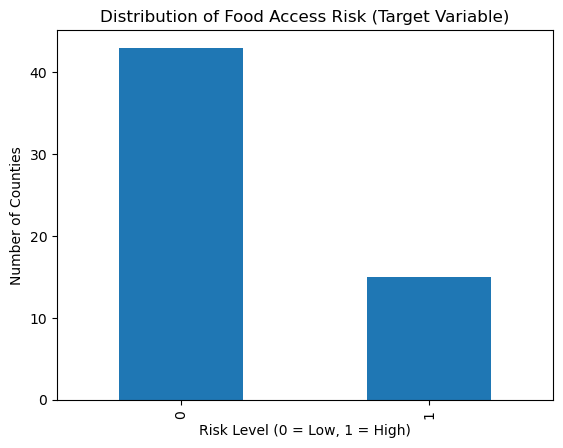

In [18]:
# Target Class distribution 

features["high_food_access_risk"].value_counts().plot(kind="bar")
plt.title("Distribution of Food Access Risk (Target Variable)")
plt.xlabel("Risk Level (0 = Low, 1 = High)")
plt.ylabel("Number of Counties")
plt.show()

In [19]:
# Check class imbalance 
print(features["high_food_access_risk"].value_counts(normalize=True))

high_food_access_risk
0    0.741379
1    0.258621
Name: proportion, dtype: float64


This dataset is small, having only 58 cases. It is also imbalanced, with only about 3 minority samples. Accuracy is not an ideal evaluation metric for this project. 

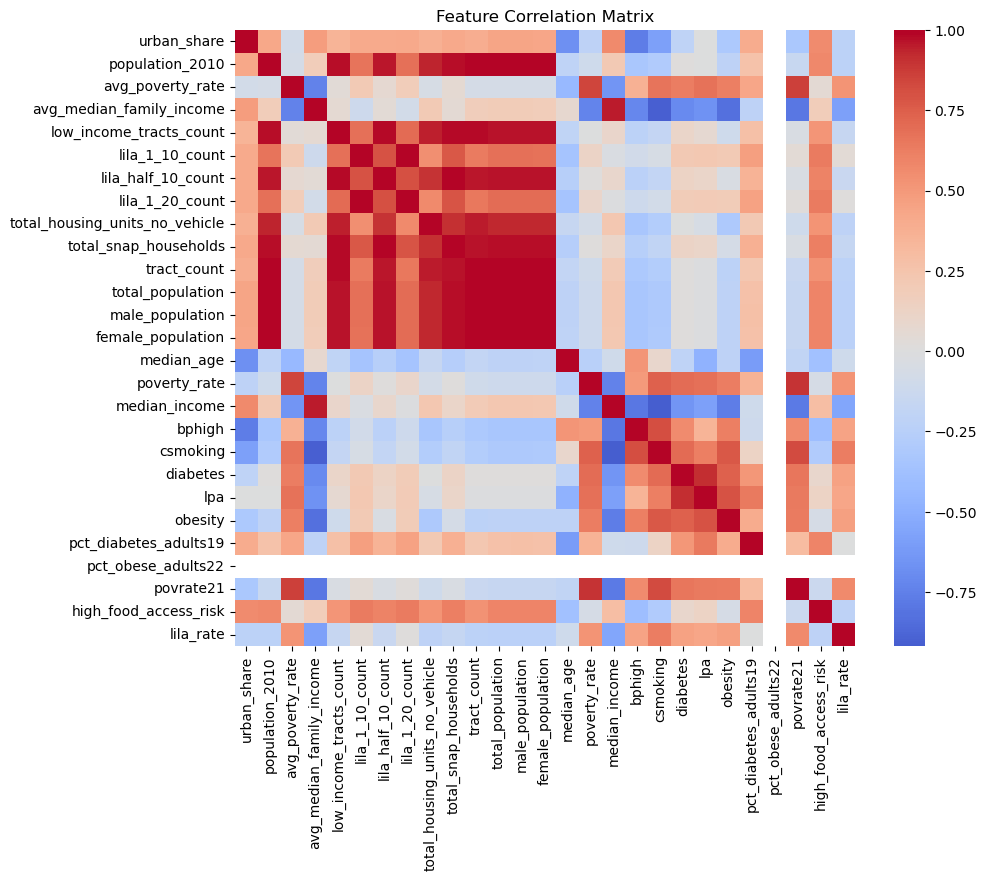

In [20]:
# Check for multicollinearity

plt.figure(figsize=(10,8))
sns.heatmap(features.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

### Regression Target 

lila_rate

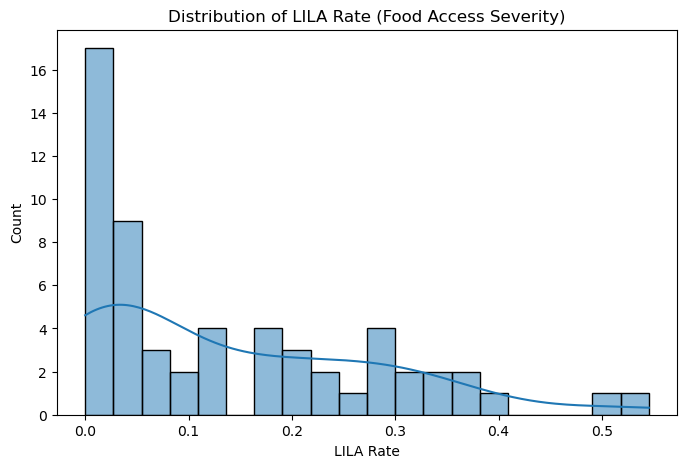

In [21]:
# Distribution plot 
plt.figure(figsize=(8,5))
sns.histplot(features["lila_rate"].dropna(), bins=20, kde=True)
plt.title("Distribution of LILA Rate (Food Access Severity)")
plt.xlabel("LILA Rate")
plt.ylabel("Count")
plt.show()

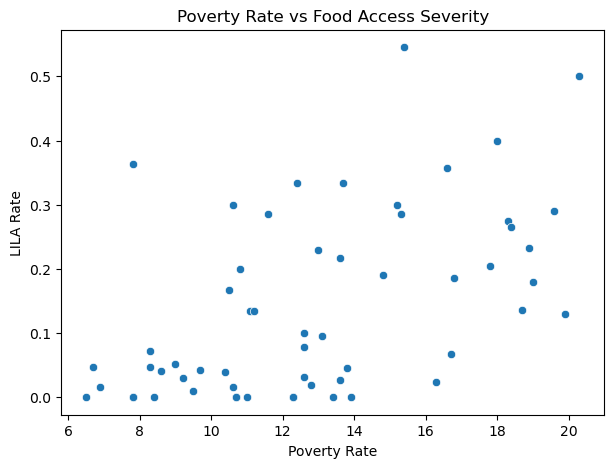

In [22]:
# Scatter plot 

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=features,
    x="poverty_rate",
    y="lila_rate"
)
plt.title("Poverty Rate vs Food Access Severity")
plt.xlabel("Poverty Rate")
plt.ylabel("LILA Rate")
plt.show()

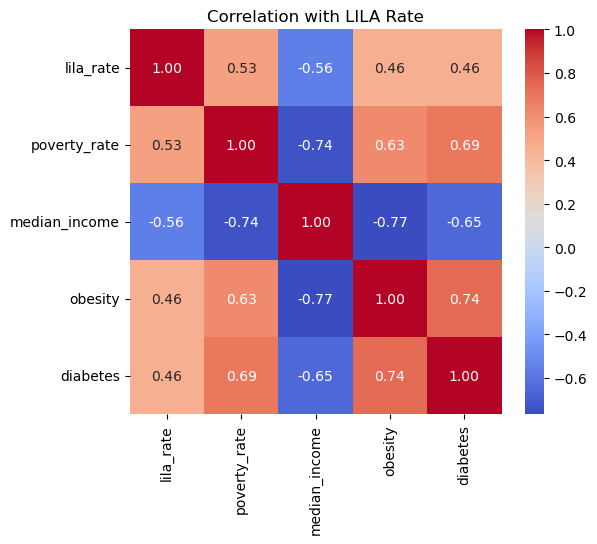

In [23]:
# Heatmap 

cols = [
    "lila_rate",
    "poverty_rate",
    "median_income",
    "obesity",
    "diabetes"
]

plt.figure(figsize=(6,5))
sns.heatmap(features[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with LILA Rate")
plt.show()

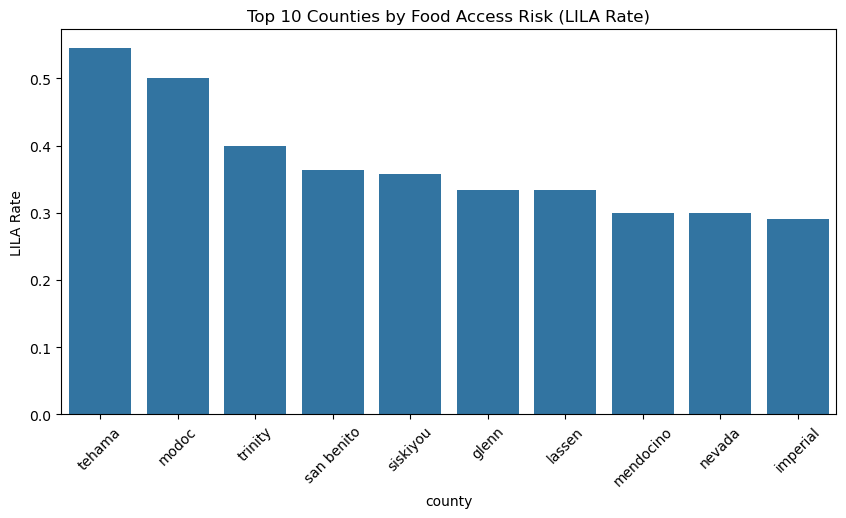

In [24]:
# Top counties 

top_counties = features.sort_values("lila_rate", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_counties,
    x="county",
    y="lila_rate"
)
plt.xticks(rotation=45)
plt.title("Top 10 Counties by Food Access Risk (LILA Rate)")
plt.ylabel("LILA Rate")
plt.show()

### Save final dataset 

In [25]:
# Ensure folder exists
os.makedirs("data/final", exist_ok=True)
# Save a local copy to Repo 
features.to_csv("data/final/nutriaccess_features_sample.csv", index=False)

## Source-Level EDA

### food_access

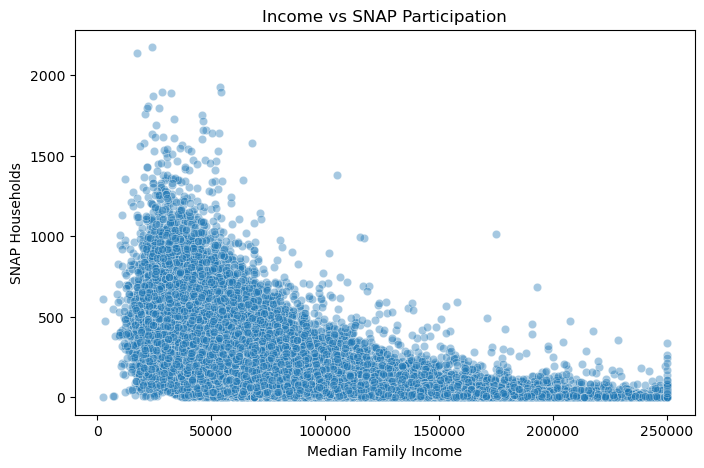

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=food_access,
    x='MedianFamilyIncome',
    y='TractSNAP',
    alpha=0.4
)

plt.title('Income vs SNAP Participation')
plt.xlabel('Median Family Income')
plt.ylabel('SNAP Households')
plt.show()

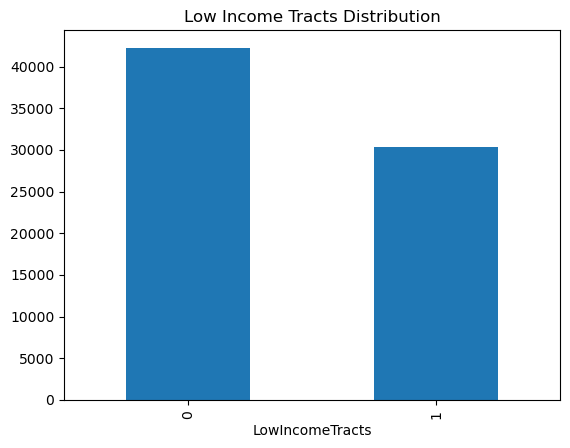

In [27]:
food_access['LowIncomeTracts'].value_counts().plot(kind='bar')
plt.title('Low Income Tracts Distribution')
plt.show()

### Census

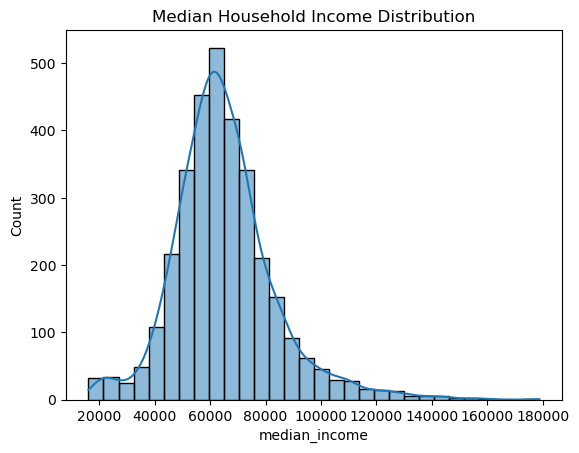

In [28]:
# Income distribution 

sns.histplot(census['median_income'].dropna(), bins=30, kde=True)
plt.title("Median Household Income Distribution")
plt.show()

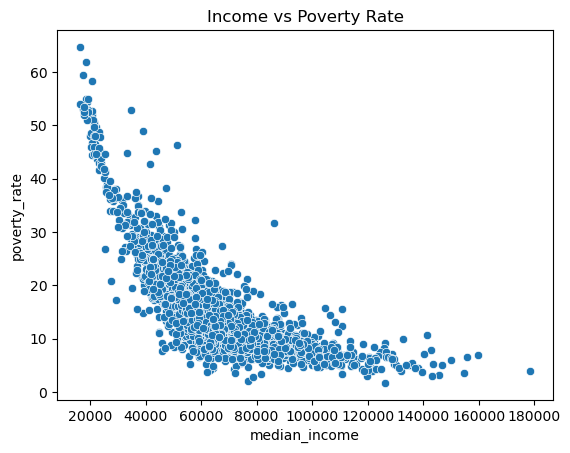

In [29]:
# Povertry vs income 

sns.scatterplot(
    data=census,
    x='median_income',
    y='poverty_rate'
)
plt.title("Income vs Poverty Rate")
plt.show()

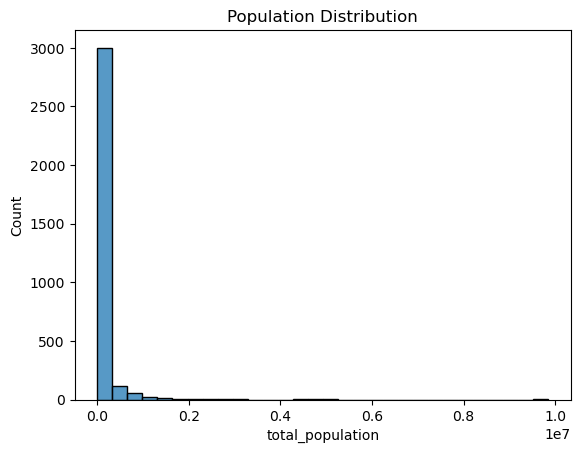

In [30]:
# Population Distribution 

sns.histplot(census['total_population'], bins=30)
plt.title("Population Distribution")
plt.show()

### PLACES

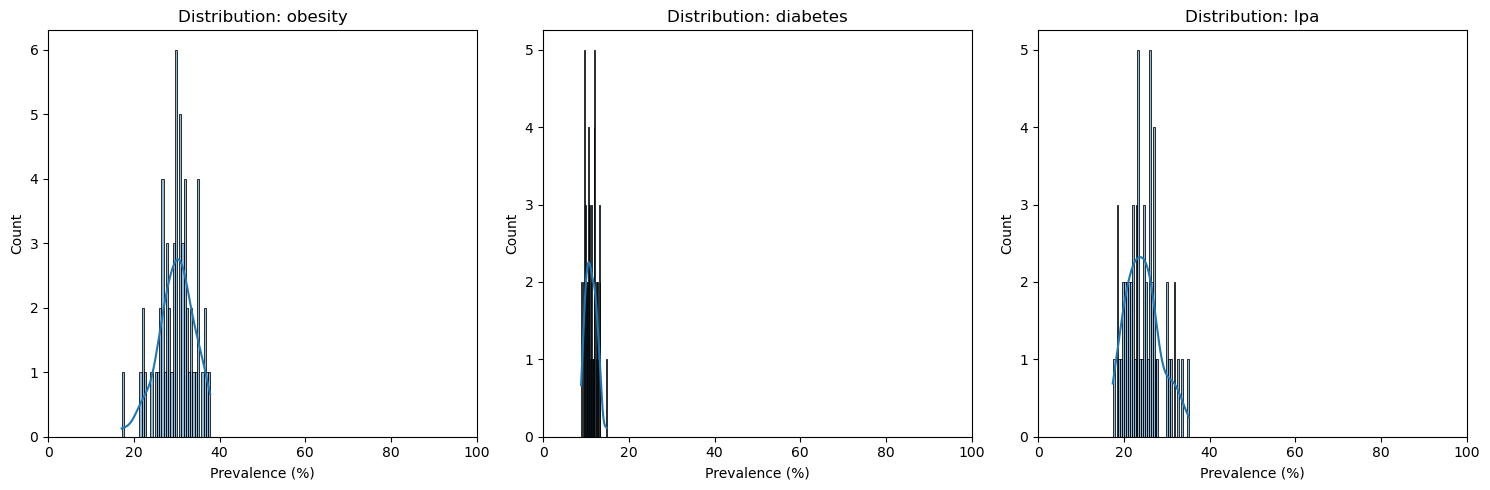

In [31]:
# Distribution of key health metrics

health_measures = ['obesity', 'diabetes', 'lpa']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, measure in zip(axes, health_measures):
    data = places[measure].dropna()
    sns.histplot(data, bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution: {measure}')
    ax.set_xlabel('Prevalence (%)')
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [32]:
# California-focused analysis
print(places.columns.tolist())
print(places.head())

ca_places = places.copy()

['state', 'county', 'bphigh', 'csmoking', 'diabetes', 'lpa', 'obesity']
        state     county  bphigh  csmoking  diabetes    lpa  obesity
0  california    alameda   27.50      9.25     10.55  20.35    22.65
1  california     alpine   31.80     11.30     10.05  18.70    28.55
2  california     amador   33.45     12.30     10.20  21.60    29.55
3  california      butte   31.35     13.35     10.30  22.75    29.95
4  california  calaveras   33.00     13.65     11.15  23.50    29.80


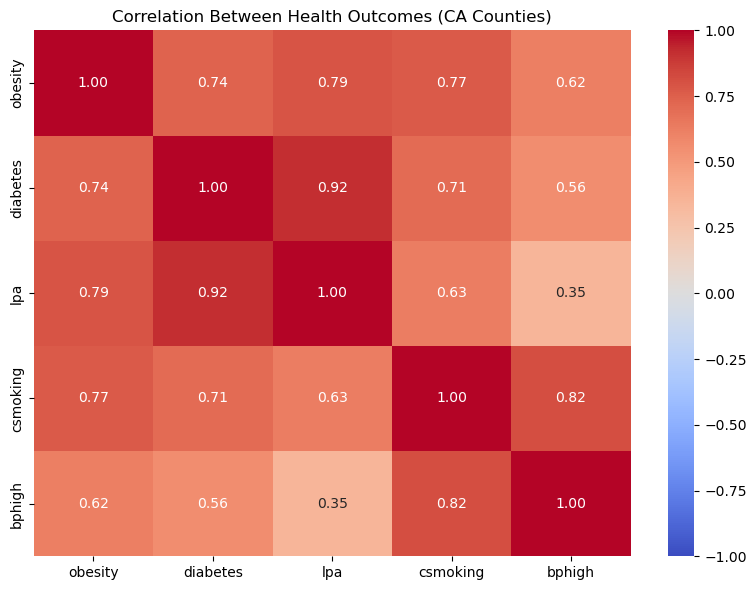

In [33]:
focus = ['obesity', 'diabetes', 'lpa', 'csmoking', 'bphigh']

plt.figure(figsize=(8, 6))
sns.heatmap(
    places[focus].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Health Outcomes (CA Counties)")
plt.tight_layout()
plt.show()

### food_env

<Axes: xlabel='povrate21', ylabel='pct_diabetes_adults19'>

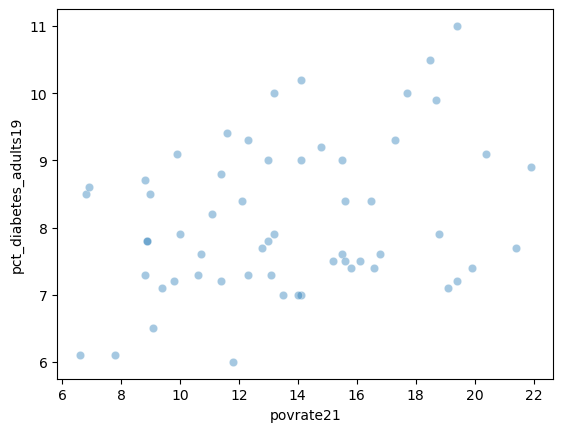

In [34]:
sns.scatterplot(
    data=food_env,
    x='povrate21',
    y='pct_diabetes_adults19',
    alpha=0.4
)

### retail_food

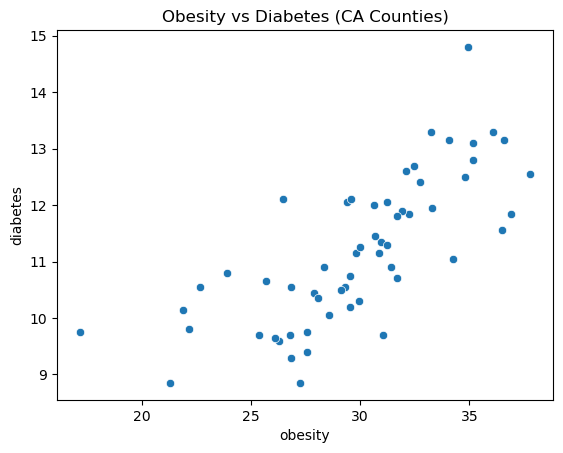

In [35]:
sns.scatterplot(
    data=ca_places,
    x='obesity',
    y='diabetes'
)
plt.title("Obesity vs Diabetes (CA Counties)")
plt.show()

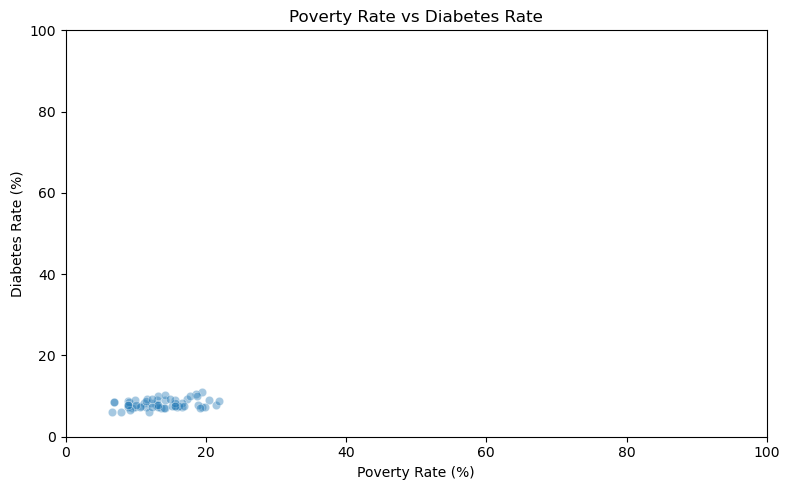

In [36]:
# Poverty vs Diabetes Scatter

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=food_env,
    x='povrate21',
    y='pct_diabetes_adults19',
    alpha=0.4
)

plt.title('Poverty Rate vs Diabetes Rate')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Diabetes Rate (%)')
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

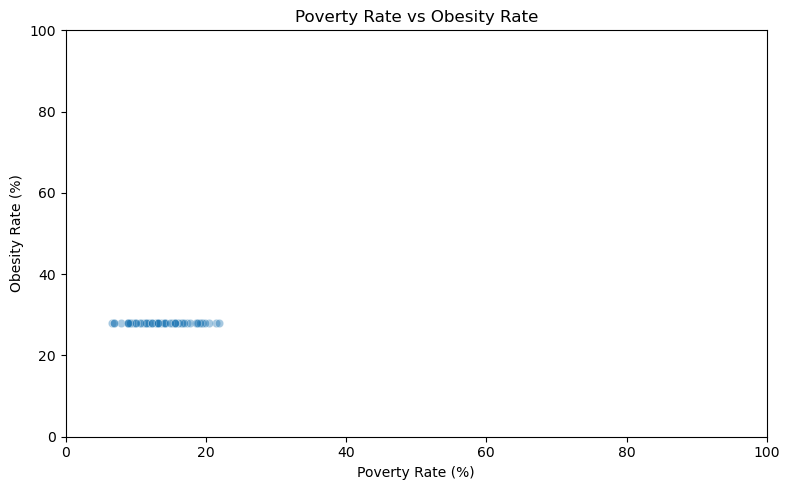

In [37]:
# Obesity vs Poverty

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=food_env,
    x='povrate21',
    y='pct_obese_adults22',
    alpha=0.4
)

plt.title('Poverty Rate vs Obesity Rate')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Obesity Rate (%)')
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

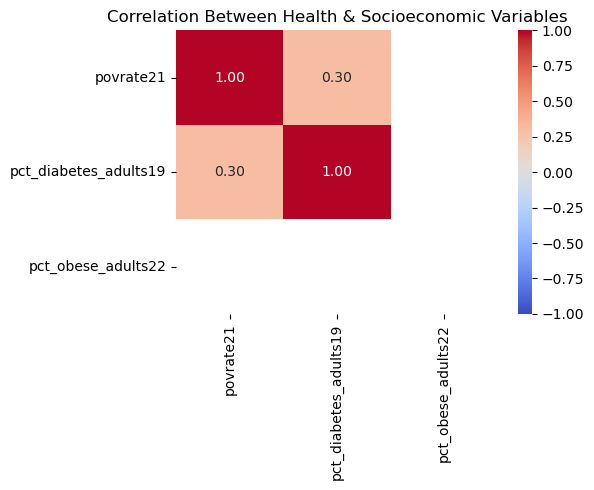

In [38]:
# Correlation Heatmap

cols = [
    'povrate21',
    'pct_diabetes_adults19',
    'pct_obese_adults22'
]

plt.figure(figsize=(6, 5))

sns.heatmap(
    food_env[cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Health & Socioeconomic Variables')
plt.tight_layout()
plt.show()

### GIS 

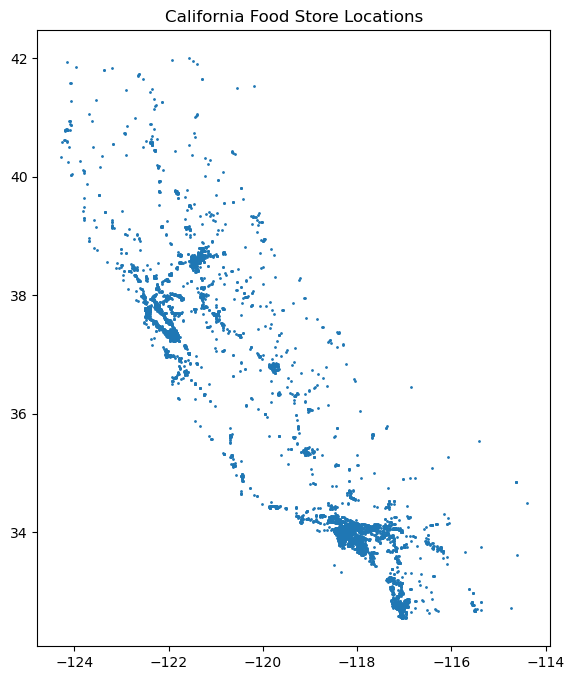

In [39]:
gdf.plot(figsize=(8,8), markersize=1)
plt.title("California Food Store Locations")
plt.show()

## Feature Selection 

Datasets were standardized and merged at the county level within the project pipeline to create a unified modeling dataset. County-level food environment data, Census demographic and socioeconomic indicators, and CDC PLACES health outcomes were integrated into a single feature table. Tract-level food access data was retained for exploratory analysis and descriptive visualizations, but not used directly in the final model due to granularity differences. The final merged dataset was stored in Parquet format to support efficient downstream modeling

The final feature set includes variables from:

    - Food environment data: county-level poverty, adult obesity, and adult diabetes indicators
    - PLACES data: smoking, high blood pressure, physical inactivity, obesity, and diabetes
    - Census data: total population, sex composition, median age, poverty rate, and median income
    - Retail food locations: geospatial food store data retained for mapping and optional future aggregation

### Merging Check 

During pipeline development, county-level join keys were standardized to support integration across food environment, Census, and PLACES datasets. The final merged feature table is now produced directly by the pipeline; however, preliminary merge checks were used during development to verify alignment across county identifiers.

Then either shorten this section or replace it with validation on features.

In [40]:
print(features.shape)
print(features.columns.tolist())
print(features[["county", "state"]].head())

(58, 29)
['state', 'county', 'urban_share', 'population_2010', 'avg_poverty_rate', 'avg_median_family_income', 'low_income_tracts_count', 'lila_1_10_count', 'lila_half_10_count', 'lila_1_20_count', 'total_housing_units_no_vehicle', 'total_snap_households', 'tract_count', 'total_population', 'male_population', 'female_population', 'median_age', 'poverty_rate', 'median_income', 'bphigh', 'csmoking', 'diabetes', 'lpa', 'obesity', 'pct_diabetes_adults19', 'pct_obese_adults22', 'povrate21', 'high_food_access_risk', 'lila_rate']
      county       state
0    alameda  california
1     alpine  california
2     amador  california
3      butte  california
4  calaveras  california


## Modeling

The goal of the model is to identify counties at elevated food access risk; recall and F1-score for the high-risk class were emphasized over overall accuracy. Balanced accuracy and ROC-AUC were used to address class imbalance and to evaluate overall classification performance.

Since the dataset is only 58 counties, hyperparameter tuning needs to stay modest by keeping parameter grids small, using 3-fold or 5-fold CV, and avoid huge search spaces. 

Exploratory modeling was first prototyped locally in notebook form. To align the project with the course requirements the final training workflow uses a SageMaker SKLearn Estimator so training runs as a managed cloud training job rather than direct notebook execution. 


In [41]:
# Modeling Imports 

from src.modeling.data_prep import prepare_model_data
from src.modeling.regression_prep import prepare_regression_data

from src.modeling.classification import (
    train_logistic_regression,
    train_decision_tree,
    train_random_forest,
    train_gradient_boosting,
)

from src.modeling.regression import (
    train_linear_regression,
    train_random_forest_regressor,
    train_gradient_boosting_regressor,
)

from src.modeling.evaluation import evaluate_classifier
from src.modeling.regression_evaluation import evaluate_regressor

from sagemaker.sklearn.estimator import SKLearn
from sagemaker.inputs import TrainingInput
import sagemaker

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


#### Save Training Data to S3 

In [42]:
# Save training dataset for SageMaker
train_df = features.copy()

train_df.to_csv("train.csv", index=False)

# Upload to S3
import boto3

s3 = boto3.client("s3")
s3.upload_file("train.csv", bucket, "processedData/train/train.csv")

print("Training data uploaded to S3")

Training data uploaded to S3


## Classification 

Predict whether a county is at high risk of food scarcity. 

Dependent variable: high_food_access_risk

In [43]:
# Prepare Data 
class_data = prepare_model_data(features)

# Train Models 
log_model = train_logistic_regression(
    class_data["X_train_scaled"],
    class_data["y_train"]
)

dt_model = train_decision_tree(
    class_data["X_train"],
    class_data["y_train"]
)

rf_model = train_random_forest(
    class_data["X_train"],
    class_data["y_train"],
    tuned=False
)

gb_model = train_gradient_boosting(
    class_data["X_train"],
    class_data["y_train"],
    tuned=True
)

Classification Metrics
----------------------
accuracy: 0.944
balanced_accuracy: 0.962
precision_class_1: 0.833
recall_class_1: 1.000
f1_class_1: 0.909
roc_auc: 1.000
pr_auc: 1.000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.83      1.00      0.91         5

    accuracy                           0.94        18
   macro avg       0.92      0.96      0.93        18
weighted avg       0.95      0.94      0.95        18



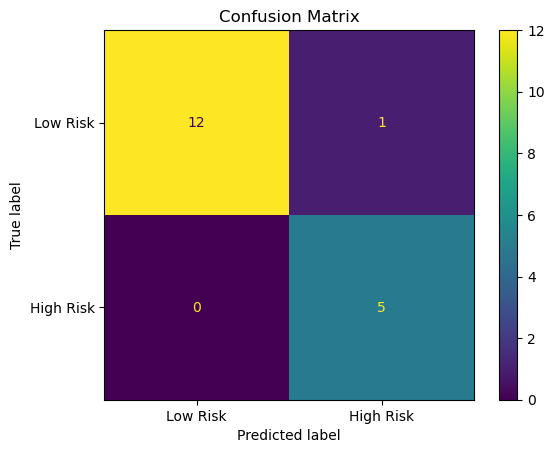


Top Coefficients:
                           Feature     Value
20           pct_diabetes_adults19  0.934246
6   total_housing_units_no_vehicle  0.789411
7            total_snap_households  0.639744
5                  lila_1_20_count  0.625349
14                   median_income  0.558122
4               lila_half_10_count  0.557361
10                 male_population  0.488763
9                 total_population  0.486046
11               female_population  0.483353
1                  population_2010  0.445861
Classification Metrics
----------------------
accuracy: 0.833
balanced_accuracy: 0.823
precision_class_1: 0.667
recall_class_1: 0.800
f1_class_1: 0.727
roc_auc: 0.823
pr_auc: 0.589

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        13
           1       0.67      0.80      0.73         5

    accuracy                           0.83        18
   macro avg       0.79      0.82      0.80        18
weighted 

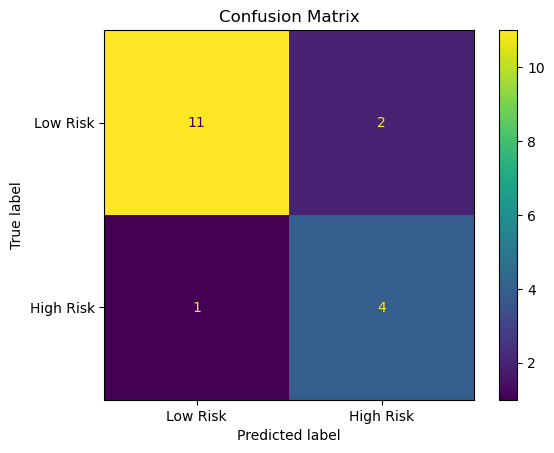


Top Feature Importances:
                           Feature     Value
6   total_housing_units_no_vehicle  0.935484
18                             lpa  0.050000
2                 avg_poverty_rate  0.014516
1                  population_2010  0.000000
3         avg_median_family_income  0.000000
4               lila_half_10_count  0.000000
5                  lila_1_20_count  0.000000
0                      urban_share  0.000000
7            total_snap_households  0.000000
8                      tract_count  0.000000
Classification Metrics
----------------------
accuracy: 1.000
balanced_accuracy: 1.000
precision_class_1: 1.000
recall_class_1: 1.000
f1_class_1: 1.000
roc_auc: 1.000
pr_auc: 1.000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         5

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
we

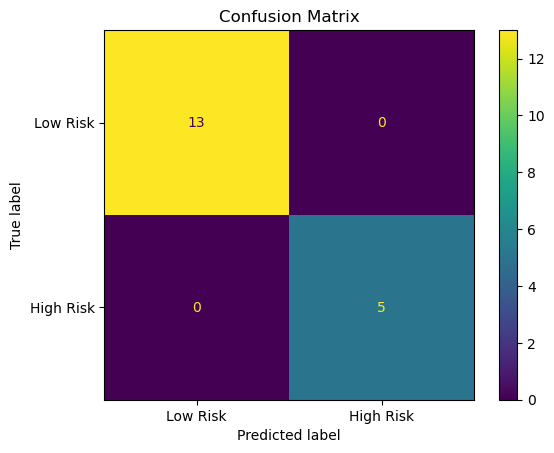


Top Feature Importances:
                           Feature     Value
7            total_snap_households  0.156568
10                 male_population  0.131312
4               lila_half_10_count  0.094506
9                 total_population  0.094479
6   total_housing_units_no_vehicle  0.088948
1                  population_2010  0.088104
11               female_population  0.083632
8                      tract_count  0.061597
5                  lila_1_20_count  0.059822
0                      urban_share  0.040222
Classification Metrics
----------------------
accuracy: 1.000
balanced_accuracy: 1.000
precision_class_1: 1.000
recall_class_1: 1.000
f1_class_1: 1.000
roc_auc: 1.000
pr_auc: 1.000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         5

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
we

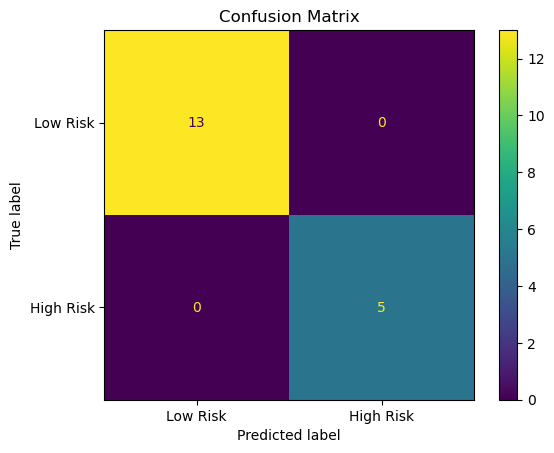


Top Feature Importances:
                           Feature     Value
7            total_snap_households  0.357932
6   total_housing_units_no_vehicle  0.216349
4               lila_half_10_count  0.192878
9                 total_population  0.112512
10                 male_population  0.032674
1                  population_2010  0.027946
0                      urban_share  0.011872
12                      median_age  0.006284
20           pct_diabetes_adults19  0.006085
14                   median_income  0.005980


In [44]:
# Evaluate Models 

metrics_log, importance_log = evaluate_classifier(
    log_model,
    class_data["X_test_scaled"],
    class_data["y_test"],
    feature_names=class_data["X"].columns
)

metrics_dt, importance_dt = evaluate_classifier(
    dt_model,
    class_data["X_test"],
    class_data["y_test"],
    feature_names=class_data["X"].columns
)

metrics_rf, importance_rf = evaluate_classifier(
    rf_model,
    class_data["X_test"],
    class_data["y_test"],
    feature_names=class_data["X"].columns
)

metrics_gb, importance_gb = evaluate_classifier(
    gb_model,
    class_data["X_test"],
    class_data["y_test"],
    feature_names=class_data["X"].columns
)

In [45]:
# Comparison Table 
classification_results = pd.DataFrame([
    {"Model": "Logistic Regression", **metrics_log},
    {"Model": "Decision Tree", **metrics_dt},
    {"Model": "Random Forest", **metrics_rf},
    {"Model": "Gradient Boosting", **metrics_gb},
])

classification_results = classification_results.sort_values(
    by="f1_class_1", ascending=False
).reset_index(drop=True)

classification_results

,Model,accuracy,balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,pr_auc
0,Gradient Boosting,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000
2,Logistic Regression,0.944444,0.961538,0.833333,1.0,0.909091,1.000000,1.000000
3,Decision Tree,0.833333,0.823077,0.666667,0.8,0.727273,0.823077,0.588889


Classification models were compared to identify counties at elevated food access risk. Because the project prioritizes identifying high-risk counties, model selection emphasized F1-score and recall for the positive class rather than overall accuracy alone.

Both Gradient Boosting and Random Forest achieved perfect performance across all evaluation metrics. While this indicates strong predictive capability, the results may be influenced by the relatively small sample size, class imbalance, and potentially strong predictor variables. As a result, these models may be overfitting or capturing patterns that may not generalize well to new data.

Logistic Regression also performed strongly, with high accuracy and F1-score, and achieved perfect recall for the positive class. This indicates that the model successfully identifies all high-risk counties, though with slightly lower precision compared to the ensemble models. This makes Logistic Regression a reliable and interpretable alternative.

The Decision Tree model showed the weakest performance across all metrics, demonstrating lower accuracy, precision, and recall. This suggests that a simple model is insufficient for capturing the complexity of the relationships in the data and serves as a useful baseline for comparison.

Given the project goal of identifying high-risk counties, Gradient Boosting was selected as the final model due to its strong performance and ability to model complex nonlinear interactions. However, its performance should be interpreted with caution due to the potential for overfitting given the limited dataset.

## Regression 

Predict whether a county is high risk AND how severe the risk is.

Dependent Variable: lila_rate 

In [46]:
# Prepare data 
reg_data = prepare_regression_data(features)

# Train Models 
lin_reg_model = train_linear_regression(
    reg_data["X_train"],
    reg_data["y_train"]
)

rf_reg_model = train_random_forest_regressor(
    reg_data["X_train"],
    reg_data["y_train"],
    tuned=True
)

gb_reg_model = train_gradient_boosting_regressor(
    reg_data["X_train"],
    reg_data["y_train"],
    tuned=False
)

In [47]:
# Evaluate models 
metrics_lin_reg, importance_lin_reg = evaluate_regressor(
    lin_reg_model,
    reg_data["X_test"],
    reg_data["y_test"],
    feature_names=reg_data["X"].columns
)

metrics_rf_reg, importance_rf_reg = evaluate_regressor(
    rf_reg_model,
    reg_data["X_test"],
    reg_data["y_test"],
    feature_names=reg_data["X"].columns
)

metrics_gb_reg, importance_gb_reg = evaluate_regressor(
    gb_reg_model,
    reg_data["X_test"],
    reg_data["y_test"],
    feature_names=reg_data["X"].columns
)

Regression Metrics
------------------
r2: -0.512
mae: 0.138
rmse: 0.176

Top Coefficients:
                           Feature     Value
0                      urban_share  0.208464
16                        csmoking  0.068962
18                             lpa  0.035753
13                    poverty_rate  0.017990
12                      median_age  0.017851
5                  lila_1_20_count  0.007224
2                 avg_poverty_rate  0.002215
4               lila_half_10_count  0.001275
14                   median_income  0.000008
6   total_housing_units_no_vehicle  0.000003
Regression Metrics
------------------
r2: 0.597
mae: 0.066
rmse: 0.091

Top Feature Importances:
                     Feature     Value
3   avg_median_family_income  0.148052
16                  csmoking  0.096636
22                 povrate21  0.073469
14             median_income  0.073395
2           avg_poverty_rate  0.062070
13              poverty_rate  0.050723
18                       lpa  0.047705
5    

In [48]:
# Comparison Table 
regression_results = pd.DataFrame([
    {"Model": "Linear Regression", **metrics_lin_reg},
    {"Model": "Random Forest Regressor", **metrics_rf_reg},
    {"Model": "Gradient Boosting Regressor", **metrics_gb_reg},
])

regression_results = regression_results.sort_values(
    by="rmse", ascending=True
).reset_index(drop=True)

regression_results

,Model,r2,mae,rmse
0,Random Forest Regressor,0.597101,0.066053,0.090756
1,Gradient Boosting Regressor,0.434031,0.073629,0.107565
2,Linear Regression,-0.512222,0.137727,0.175826


Regression models were compared to predict lila_rate, which provides a more granular measure of food access severity. Model performance was evaluated using RMSE, MAE, and R² to assess both predictive accuracy and explanatory strength.

The Random Forest Regressor was the best-performing model, achieving an R² of approximately 0.60 along with the lowest MAE and RMSE values. This indicates that the model explains about 60% of the variance in food access risk while maintaining relatively low prediction error.

The Gradient Boosting Regressor also performed well but underperformed compared to the Random Forest model, with slightly worse error metrics and a lower R² value of approximately 0.43.

In contrast, the Linear Regression model was the weakest performer, with a negative R² value of -0.51. This indicates that the model performs worse than predicting the mean of the target variable, suggesting that the relationships between predictors and food access risk are not purely linear and that the model fails to capture the underlying complexity of the data.

These results suggest that food access risk is driven by nonlinear relationships. Therefore, ensemble models are better suited for capturing the complexity of food access patterns. Based on these findings, the Random Forest Regressor was selected as the final model for predicting lila_rate.

## Best Model Summary 

In [49]:
best_classification_model = classification_results.iloc[0]
best_regression_model = regression_results.iloc[0]

print("Best classification model:")
print(best_classification_model)

print("\nBest regression model:")
print(best_regression_model)

Best classification model:
Model                Gradient Boosting
accuracy                           1.0
balanced_accuracy                  1.0
precision_class_1                  1.0
recall_class_1                     1.0
f1_class_1                         1.0
roc_auc                            1.0
pr_auc                             1.0
Name: 0, dtype: object

Best regression model:
Model    Random Forest Regressor
r2                      0.597101
mae                     0.066053
rmse                    0.090756
Name: 0, dtype: object


The best-performing classification model was Gradient Boosting, achieving perfect scores across all evaluation metrics, including accuracy, F1-score, recall, and ROC-AUC. While this indicates strong predictive performance, these results should be interpreted with caution due to the relatively small sample size and potential class imbalance, which may contribute to overfitting. Nevertheless, Gradient Boosting was selected as the final classification model due to its ability to capture complex nonlinear relationships and its strong overall performance.

The best-performing regression model was the Random Forest Regressor, with an R² of approximately 0.60 and the lowest MAE and RMSE values among the models tested. This indicates that the model explains a substantial portion of the variance in food access risk while maintaining relatively low prediction error. Compared to other models, Random Forest demonstrated a better ability to capture nonlinear relationships in the data.

Together, these results suggest that nonlinear ensemble methods are most effective for modeling food access risk. The combination of Gradient Boosting for classification and Random Forest for regression provides a robust framework for identifying high-risk counties and estimating the severity of food access challenges.

In [50]:
# SageMaker Training Job (Cloud Training)
sess = sagemaker.Session()
role = sagemaker.get_execution_role()

# S3 path (reuse your bucket variable)
train_path = f"s3://{bucket}/processedData/train/"

estimator = SKLearn(
    entry_point="train_classifier.py",
    source_dir="src/modeling",
    role=role,
    instance_type="ml.m5.large",
    framework_version="1.2-1",
    py_version="py3",
    output_path=f"s3://{bucket}/model-artifacts/"
)

print("Starting SageMaker training job...")

estimator.fit({
    "train": TrainingInput(train_path, content_type="text/csv")},
    logs=False
)

print("Training job complete!")
print("Model artifacts saved to:", estimator.output_path)

Starting SageMaker training job...


INFO:sagemaker:Creating training-job with name: sagemaker-scikit-learn-2026-04-08-14-14-58-962



2026-04-08 14:15:01 Starting - Starting the training job..
2026-04-08 14:15:17 Starting - Preparing the instances for training...
2026-04-08 14:15:39 Downloading - Downloading input data.....
2026-04-08 14:16:10 Downloading - Downloading the training image.............
2026-04-08 14:17:16 Training - Training image download completed. Training in progress..
2026-04-08 14:17:26 Uploading - Uploading generated training model.
2026-04-08 14:17:39 Completed - Training job completed
Training job complete!
Model artifacts saved to: s3://nutriaccess-data/model-artifacts/


Model training was performed using Amazon SageMaker’s managed Scikit-learn estimator, which executed a custom training script on cloud infrastructure and stored model artifacts in Amazon S3.

While both classification and regression models were developed and evaluated during the modeling phase, only the best-performing classification model was selected for cloud-based training in Amazon SageMaker. This approach reflects real-world machine learning workflows, where only finalized models are operationalized for scalability and deployment.

# Conclusion 

Access to healthy and affordable food is a critical public health issue. Many communities face barriers such as distance, income, and limited infrastructure, resulting in what are commonly known as food deserts.

To better understand this issue, our hypothetical company, NutriAccess, integrated datasets from the USDA (food access), U.S. Census (income and demographics), and CDC (health outcomes). These data sources were combined into a unified data pipeline designed to answer a key question: **Can we identify which counties are most at risk, and quantify how severe that risk is?** 

*Due to time and data constraints, the project prioritized predictive modeling of high-risk communities, while exploratory questions provided context for interpretation.* 

To address the key question, two complementary modeling approaches were implemented. Classification models were used to identify counties at high risk of limited food access, while regression models were used to estimate the severity of that risk using the LILA (Low Income Low Access) rate.

The results provide two important insights. First, classification modeling was able to accurately identify high-risk counties, enabling more targeted interventions. Second, regression modeling revealed that food access risk varies significantly across counties, and that nonlinear models are better suited to capture this complexity.

While some models achieved near-perfect performance, these results should be interpreted with caution. The relatively small dataset and class imbalance likely contributed to overfitting, meaning the models may be capturing patterns specific to this dataset rather than generalizable trends. Therefore, the findings should be viewed as directional insights rather than definitive predictions.

In addition to modeling, the project incorporated a cloud-based data validation and query layer using Amazon Athena and AWS Glue. This enabled efficient exploration of large, structured datasets stored in S3 and supported validation of key patterns related to food access, socioeconomic conditions, and health outcomes prior to modeling.

Overall, this analysis demonstrates how data-driven approaches can help identify and prioritize communities most in need, supporting more informed decision-making and promoting more equitable access to healthy food.

## Future Enhancements

This pipeline could be extended into a decision-support tool for identifying food deserts in real time.

Key areas for future improvement include:

1. Expanding the size, coverage, and granularity of the dataset  
2. Strengthening the modeling framework through more rigorous validation and hyperparameter tuning  
3. Extending the pipeline into a more operational, user-facing decision-support system  